# Hyperparameter Analysis — Perturbation Method

**Date**: 2026-02-25  
**Purpose**: Diagnostic analysis of ALL existing experiments (completed, running, and killed) to guide Phase 1 hyperparameter sweep.

Parses both `saved_records/` logs and SLURM stderr traces in `logs/slurm/` for comprehensive coverage.

---

## Key questions:
1. What sigma values work best for each problem?
2. How does the sigma/|coeff_hat| ratio relate to regret?
3. What are the per-epoch runtimes for n=1 vs n=25?
4. Where does perturb rank vs baselines?

In [59]:
import os, glob, re, json
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = "/cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark"
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

Working directory: /cluster/tufts/hugheslab/kheuto01/code/PredictiveCO-Benchmark


## 1. Auto-discover ALL perturb experiments

Scans `saved_records/*/perturb/*/log.txt` and `logs/slurm/pco_*.err` to find every experiment ever run, including killed/preempted jobs not tracked in sigma_experiments.ipynb.

In [60]:
def parse_log_file(log_path):
    """Parse a saved_records log.txt for key metrics.
    Returns dict with status, hyperparams, per-epoch curves, and final results."""
    if not os.path.exists(log_path):
        return None
    with open(log_path, "r") as f:
        content = f.read()
    
    info = {"log_path": log_path, "status": "unknown", "epochs": []}
    
    # Extract hyperparams from Namespace line
    ns_match = re.search(r"Namespace\((.*?)\)", content)
    if ns_match:
        ns_str = ns_match.group(1)
        for key in ["lr", "patience", "n_epochs", "seed"]:
            m = re.search(rf"{key}=([\d.eE\-+]+)", ns_str)
            if m:
                info[key] = float(m.group(1))
    
    # Extract perturb config: {'sigma': ..., 'n_samples': ..., 'noise': ...}
    cfg_match = re.search(r"perturb.*?hyperparams:\s*(\{.*?\})", content, re.DOTALL)
    if cfg_match:
        try:
            cfg_str = cfg_match.group(1).replace("'", '"')
            cfg = json.loads(cfg_str)
            info.update({f"cfg_{k}": v for k, v in cfg.items()})
        except:
            pass
    
    # Fallback: parse model config line
    if "cfg_sigma" not in info:
        sigma_m = re.search(r"'sigma':\s*([\d.eE\-+]+)", content)
        if sigma_m:
            info["cfg_sigma"] = float(sigma_m.group(1))
        ns_m = re.search(r"'n_samples':\s*(\d+)", content)
        if ns_m:
            info["cfg_n_samples"] = int(ns_m.group(1))
        noise_m = re.search(r"'noise':\s*'(\w+)'", content)
        if noise_m:
            info["cfg_noise"] = noise_m.group(1)
    
    # Extract optimal objective
    opt_match = re.search(r'\[Optimal Obj\]:\s*([\d.\-eE+]+)', content)
    if opt_match:
        info["optimal_obj"] = float(opt_match.group(1))
    
    # Parse per-epoch data
    current_epoch = {}
    for line in content.split("\n"):
        m = re.search(r'\[perturb\] epoch (\d+): \|coeff_hat\| = ([\d.]+), sigma = ([\d.]+)', line)
        if m:
            current_epoch = {
                "epoch": int(m.group(1)),
                "coeff_hat": float(m.group(2)),
                "sigma": float(m.group(3)),
            }
        m_train = re.search(r'Iter \d+, train\s+Objective:\s+(-?[\d.]+).*regret:\s+([\d.]+)', line)
        if m_train and current_epoch:
            current_epoch["train_obj"] = float(m_train.group(1))
            current_epoch["train_regret"] = float(m_train.group(2))
        m_val = re.search(r'Iter \d+, val\s+Objective:\s+(-?[\d.]+).*regret:\s+([\d.]+)', line)
        if m_val and current_epoch:
            current_epoch["val_obj"] = float(m_val.group(1))
            current_epoch["val_regret"] = float(m_val.group(2))
            info["epochs"].append(current_epoch)
            current_epoch = {}
    
    # Check final result
    final_match = re.search(
        r'\[perturb\]\s+([\d.\-eE+]+)\s+([\d.\-eE+]+)\s+([\d.\-eE+]+)\s+([\d.\-eE+]+)\s*$',
        content, re.MULTILINE
    )
    if final_match:
        info["status"] = "DONE"
        info["test_obj"] = float(final_match.group(1))
        info["test_regret"] = float(final_match.group(2))
        info["train_time"] = float(final_match.group(3))
        info["test_time"] = float(final_match.group(4))
    elif info["epochs"]:
        info["status"] = "running"
    
    # Avg train/test time
    train_t = re.search(r'\[avg Train Time\]:\s*([\d.]+)s', content)
    test_t = re.search(r'\[avg Test Time\]:\s*([\d.]+)s', content)
    if train_t:
        info["avg_train_time_per_batch"] = float(train_t.group(1))
    if test_t:
        info["avg_test_time_per_batch"] = float(test_t.group(1))
    
    return info


def check_preemption(problem_key, prefix, slurm_err_dir="logs/slurm"):
    """Check if any SLURM .err file for this job shows preemption.
    Returns (preempted: bool, job_id: str or None)."""
    # Match pattern: pco_{problem_key}_{prefix}_{jobid}.err
    pattern = os.path.join(slurm_err_dir, f"pco_*{prefix}*.err")
    err_files = sorted(glob.glob(pattern))
    for ef in err_files:
        try:
            with open(ef, "r") as f:
                tail = f.read()[-500:]  # only check last 500 chars
            if "DUE TO PREEMPTION" in tail or "CANCELLED" in tail:
                job_m = re.search(r'JOB (\d+)', tail)
                return True, job_m.group(1) if job_m else None
        except:
            pass
    return False, None


# ── Discover all perturb experiments ──
all_logs = sorted(glob.glob("saved_records/*/perturb/*/log.txt"))
print(f"Found {len(all_logs)} perturb log files\n")

records = []
for log_path in all_logs:
    parts = log_path.split("/")
    data_name = parts[1]
    prefix = parts[3]
    
    info = parse_log_file(log_path)
    if info is None:
        continue
    
    n_epochs = len(info["epochs"])
    best_val_regret = min((e.get("val_regret", float("inf")) for e in info["epochs"]), default=np.nan)
    best_epoch = None
    if info["epochs"]:
        best_epoch = min(info["epochs"], key=lambda e: e.get("val_regret", float("inf"))).get("epoch")
    
    # Sigma/coeff ratio at best epoch
    sigma_coeff_ratio = np.nan
    if info["epochs"]:
        best_e = [e for e in info["epochs"] if e.get("epoch") == best_epoch]
        if best_e and best_e[0].get("coeff_hat", 0) > 0:
            sigma_coeff_ratio = best_e[0].get("sigma", 0) / best_e[0]["coeff_hat"]
    
    # Final test regret and %regret
    test_regret = info.get("test_regret", np.nan)
    optimal = info.get("optimal_obj", np.nan)
    pct_regret = (test_regret / optimal * 100) if (optimal and not np.isnan(optimal) and optimal != 0 and not np.isnan(test_regret)) else np.nan
    
    # Check for preemption if status is unknown or running
    status = info["status"]
    if status in ("unknown", "running"):
        preempted, job_id = check_preemption(data_name, prefix)
        if preempted:
            status = "PREEMPTED"
    
    records.append({
        "data_name": data_name,
        "prefix": prefix,
        "status": status,
        "sigma": info.get("cfg_sigma", np.nan),
        "n_samples": info.get("cfg_n_samples", np.nan),
        "noise": info.get("cfg_noise", "normal"),
        "lr": info.get("lr", np.nan),
        "patience": info.get("patience", np.nan),
        "n_epochs_ran": n_epochs,
        "best_epoch": best_epoch,
        "best_val_regret": best_val_regret,
        "test_regret": test_regret,
        "optimal_obj": optimal,
        "pct_regret": pct_regret,
        "sigma_coeff_ratio": sigma_coeff_ratio,
        "avg_train_time": info.get("avg_train_time_per_batch", np.nan),
    })

df = pd.DataFrame(records)
print(f"Total experiments discovered: {len(df)}")
print(f"  DONE:      {(df['status'] == 'DONE').sum()}")
print(f"  Running:   {(df['status'] == 'running').sum()}")
print(f"  PREEMPTED: {(df['status'] == 'PREEMPTED').sum()}")
print(f"  Unknown:   {(df['status'] == 'unknown').sum()}")

if (df['status'] == 'PREEMPTED').any():
    print("\n⚠ Preempted experiments (need resubmission):")
    preempted = df[df['status'] == 'PREEMPTED'][['data_name', 'prefix', 'sigma', 'n_epochs_ran']]
    print(preempted.to_string(index=False))

print()

# Show summary grouped by problem
for dn in sorted(df["data_name"].unique()):
    sub = df[df["data_name"] == dn].sort_values("test_regret", na_position="last")
    print(f"\n{'='*120}")
    print(f"  {dn}  (optimal={sub['optimal_obj'].dropna().iloc[0] if len(sub['optimal_obj'].dropna()) else '?'})")
    print(f"{'='*120}")
    cols = ["prefix", "status", "sigma", "n_samples", "noise", "lr", "n_epochs_ran", 
            "best_epoch", "best_val_regret", "test_regret", "pct_regret", "sigma_coeff_ratio"]
    print(sub[cols].to_string(index=False))

Found 234 perturb log files

Total experiments discovered: 234
  DONE:      178
  Running:   10
  PREEMPTED: 40
  Unknown:   6

⚠ Preempted experiments (need resubmission):
             data_name                                prefix  sigma  n_epochs_ran
      advertising-real                         bench_perturb 0.5000             0
bipartitematching-cora                         bench_perturb 0.5000             2
      budgetalloc-real                   bench_perturb_s0001 0.0010            46
      budgetalloc-real             bench_perturb_s0001_lr1e3 0.0010            63
      budgetalloc-real             bench_perturb_s0001_lr5e3 0.0010            62
      budgetalloc-real                    sched_budget_lr1e3 0.0100            63
      budgetalloc-real                         sweep_s005_n1 0.0500             0
      budgetalloc-real tanh_schedule_perturb_linsched_budget 0.0100            64
         energy-energy                 bench_energy_n1_lr1e3 0.0100             8
       

## 2. Sigma vs Regret — per problem

Scatter/line plots showing how sigma affects regret for each problem. Separate traces for different noise types and n_samples.

/tmp/ipykernel_1749397/1637139611.py:29: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(row["sigma"], row["test_regret"], c=color, marker=marker, s=80,
/tmp/ipykernel_1749397/1637139611.py:29: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(row["sigma"], row["test_regret"], c=color, marker=marker, s=80,
/tmp/ipykernel_1749397/1637139611.py:29: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(row["sigma"], row["test_regret"], c=color, marker=marker, s=80,


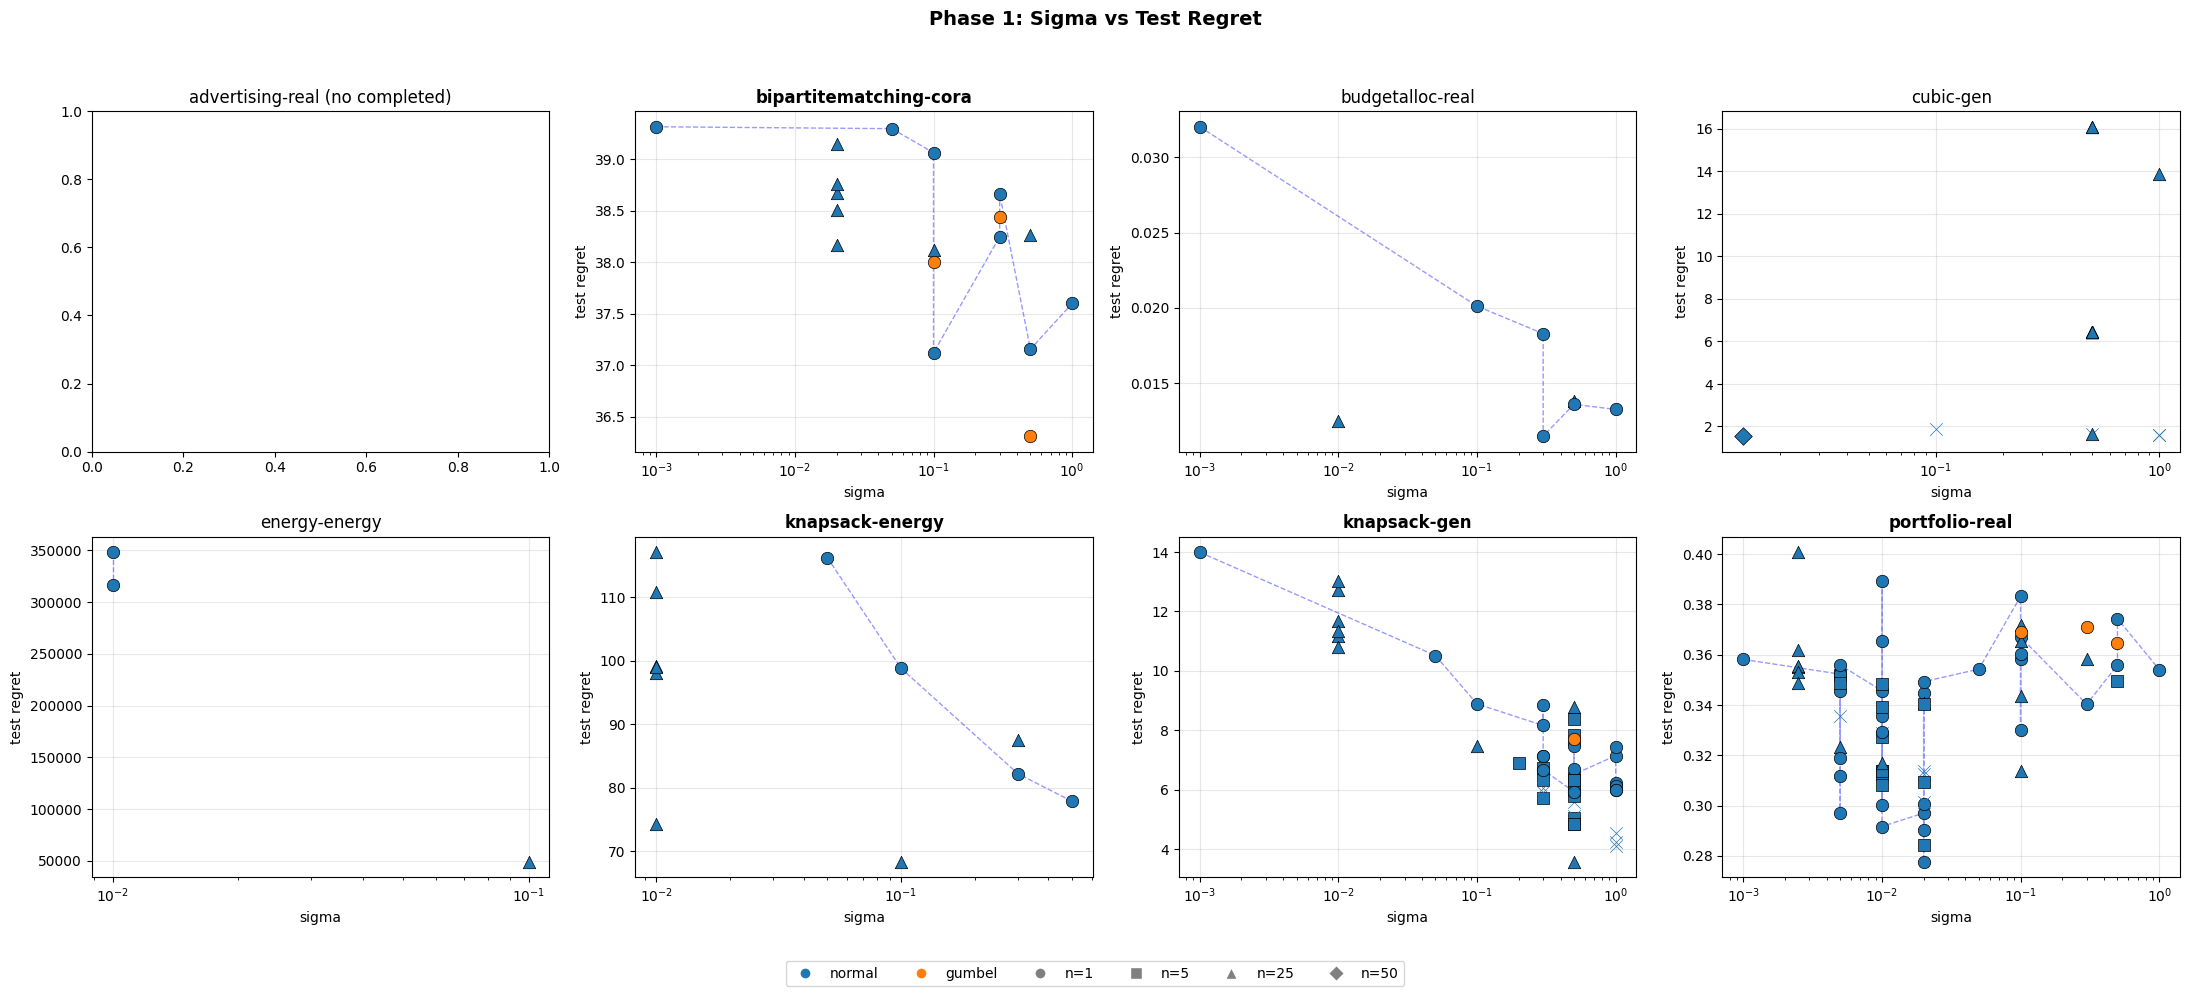

In [61]:
done_df = df[df["status"] == "DONE"].copy()

# Problems of interest
priority_problems = ["portfolio-real", "bipartitematching-cora", "knapsack-gen", "knapsack-energy"]
all_problems = sorted(df["data_name"].unique())

# ── Sigma vs Regret scatter ──
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for idx, data_name in enumerate(all_problems):
    if idx >= 8:
        break
    ax = axes_flat[idx]
    sub = done_df[done_df["data_name"] == data_name].copy()
    if sub.empty:
        ax.set_title(data_name + " (no completed)")
        continue
    
    # Color by noise type, marker by n_samples
    noise_colors = {"normal": "tab:blue", "gumbel": "tab:orange"}
    nsample_markers = {1: "o", 5: "s", 25: "^", 50: "D"}
    
    for _, row in sub.iterrows():
        noise = str(row.get("noise", "normal"))
        ns = int(row["n_samples"]) if not np.isnan(row["n_samples"]) else 25
        color = noise_colors.get(noise, "tab:gray")
        marker = nsample_markers.get(ns, "x")
        ax.scatter(row["sigma"], row["test_regret"], c=color, marker=marker, s=80, 
                   edgecolors="black", linewidth=0.5, zorder=3)
    
    # Connect n=1 normal dots with line
    n1_normal = sub[(sub["n_samples"] == 1) & (sub["noise"].fillna("normal") == "normal")].sort_values("sigma")
    if len(n1_normal) > 1:
        ax.plot(n1_normal["sigma"], n1_normal["test_regret"], "b--", alpha=0.4, linewidth=1)
    
    ax.set_xscale("log")
    ax.set_xlabel("sigma")
    ax.set_ylabel("test regret")
    ax.set_title(data_name, fontweight="bold" if data_name in priority_problems else "normal")
    ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=8, label='gumbel'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='n=1'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='n=5'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='n=25'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=8, label='n=50'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=10)
fig.suptitle("Phase 1: Sigma vs Test Regret", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## 3. Baseline Comparison Leaderboard

Compare perturb results against baseline methods. Baselines (from sigma_experiments.ipynb):
- **portfolio**: pointLTR 0.215, listLTR 0.345, pairLTR 0.264
- **bipartite**: pointLTR 38.5, pairLTR 47.2
- **knapsack-gen**: pointLTR 7.80, pairLTR 3.19
- **knapsack-energy**: pointLTR 68.6
- **budget**: pointLTR 0.020, pairLTR 0.014
- **energy**: pointLTR 53770

In [62]:
# Known baselines (test regret from sigma_experiments.ipynb)
BASELINES = {
    "portfolio-real": {"pointLTR": 0.215, "listLTR": 0.345, "pairLTR": 0.264},
    "bipartitematching-cora": {"pointLTR": 38.5, "pairLTR": 47.2},
    "knapsack-gen": {"pointLTR": 7.80, "pairLTR": 3.19},
    "knapsack-energy": {"pointLTR": 68.6},
    "budgetalloc-real": {"pointLTR": 0.020, "pairLTR": 0.014},
    "energy-energy": {"pointLTR": 53770},
    "cubic-gen": {"pointLTR": 0.08},
}

print(f"{'Problem':<25} {'Best Perturb':>14} {'Config':<40} {'Best Baseline':>14} {'Baseline':>10} {'Gap':>10}")
print("=" * 120)

for data_name in sorted(done_df["data_name"].unique()):
    sub = done_df[done_df["data_name"] == data_name]
    best_row = sub.loc[sub["test_regret"].idxmin()]
    best_perturb = best_row["test_regret"]
    
    cfg_str = f"σ={best_row['sigma']}, n={int(best_row['n_samples']) if not np.isnan(best_row['n_samples']) else '?'}"
    cfg_str += f", {best_row.get('noise', 'normal')}"
    cfg_str += f", lr={best_row['lr']}" if not np.isnan(best_row.get("lr", np.nan)) else ""
    
    baselines = BASELINES.get(data_name, {})
    if baselines:
        best_bl_name = min(baselines, key=baselines.get)
        best_bl_val = baselines[best_bl_name]
        gap = best_perturb - best_bl_val
        gap_str = f"{gap:+.4f}" if abs(gap) < 1000 else f"{gap:+.0f}"
        winner = "✓ BETTER" if best_perturb < best_bl_val else "✗ WORSE"
    else:
        best_bl_name = "—"
        best_bl_val = np.nan
        gap_str = "—"
        winner = ""
    
    print(f"{data_name:<25} {best_perturb:>14.4f} {cfg_str:<40} {best_bl_val:>14.4f} {best_bl_name:>10} {gap_str:>10} {winner}")

print()
print("Gap = perturb - baseline (negative = perturb is better)")

Problem                     Best Perturb Config                                    Best Baseline   Baseline        Gap
bipartitematching-cora           36.3112 σ=0.5, n=1, gumbel, lr=0.005                    38.5000   pointLTR    -2.1888 ✓ BETTER
budgetalloc-real                  0.0115 σ=0.3, n=1, normal, lr=0.005                     0.0140    pairLTR    -0.0025 ✓ BETTER
cubic-gen                         1.5470 σ=0.01375, n=50, normal, lr=0.01                 0.0800   pointLTR    +1.4670 ✗ WORSE
energy-energy                 49265.1110 σ=0.1, n=25, normal, lr=0.01                 53770.0000   pointLTR      -4505 ✓ BETTER
knapsack-energy                  68.3398 σ=0.1, n=25, normal, lr=0.01                    68.6000   pointLTR    -0.2602 ✓ BETTER
knapsack-gen                      3.5800 σ=0.5, n=25, normal, lr=0.005                    3.1900    pairLTR    +0.3900 ✗ WORSE
portfolio-real                    0.2777 σ=0.02, n=1, normal, lr=0.002                    0.2150   pointLTR    +0.0

## 4. Sigma / |coeff_hat| Ratio Analysis

The ratio σ/|ĉ| controls the effective perturbation magnitude. If σ/|ĉ| ≫ 1, the perturbation dominates and the solver ignores the prediction. If σ/|ĉ| ≪ 0.01, the perturbation is too small and gradients vanish.

/tmp/ipykernel_1749397/2735449076.py:44: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


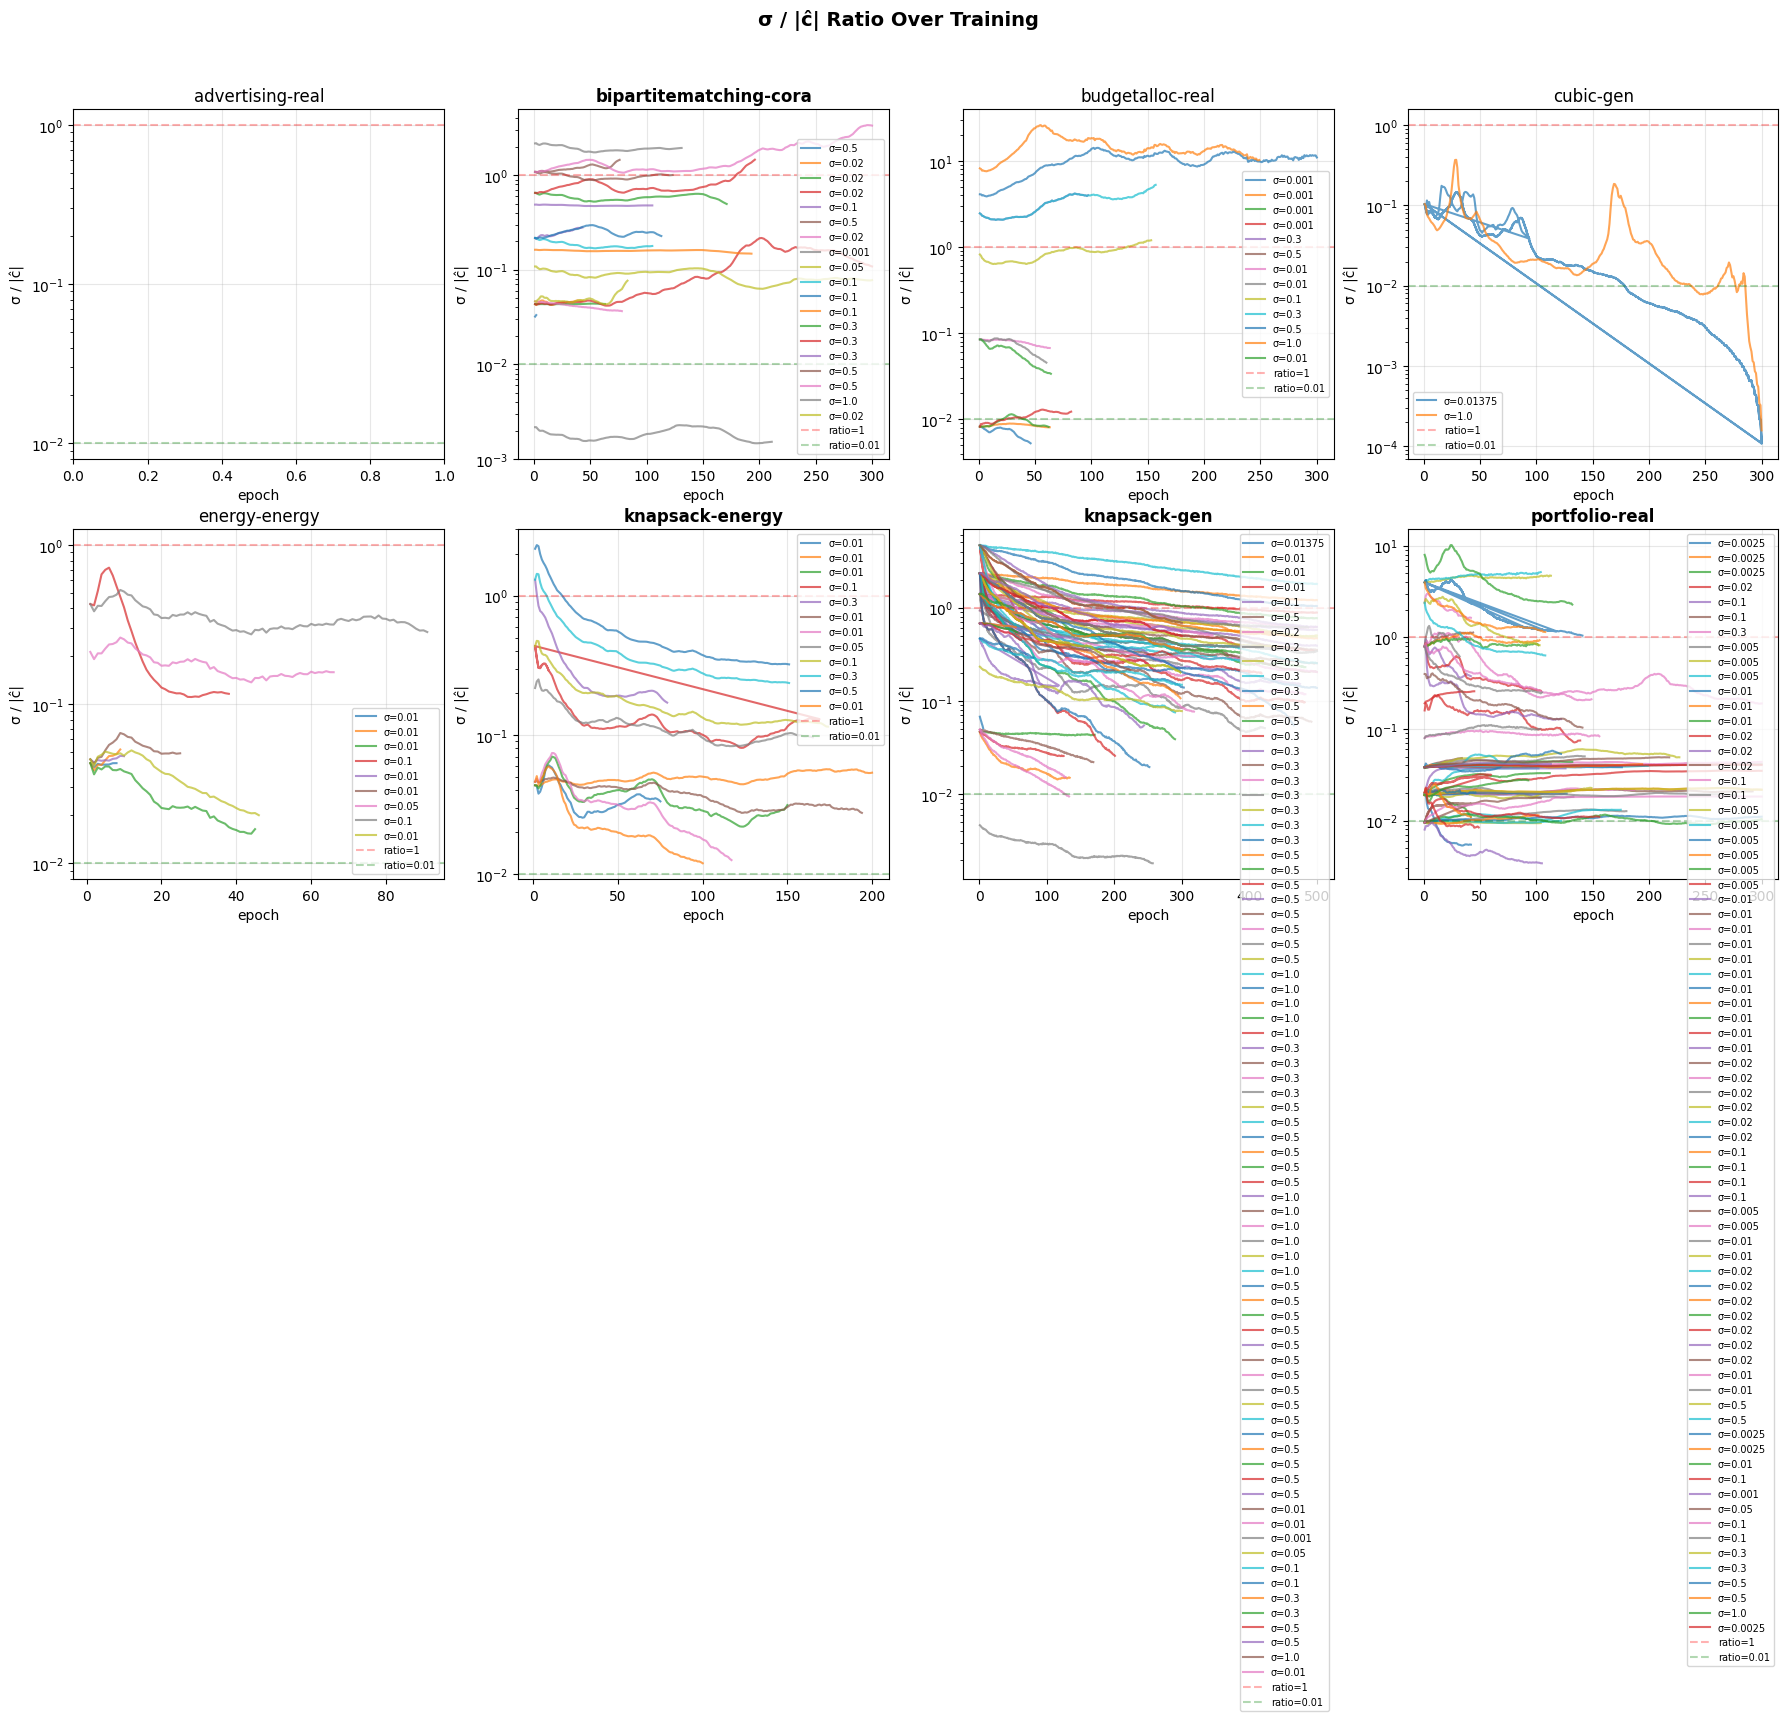

In [63]:
# Parse sigma/|coeff_hat| ratio over training from log files
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for idx, data_name in enumerate(all_problems):
    if idx >= 8:
        break
    ax = axes_flat[idx]
    sub_logs = [lp for lp in all_logs if data_name in lp]
    
    has_data = False
    for log_path in sub_logs:
        info = parse_log_file(log_path)
        if info is None or not info["epochs"]:
            continue
        
        epochs_with_ratio = [(e["epoch"], e["sigma"] / e["coeff_hat"]) 
                            for e in info["epochs"] 
                            if e.get("coeff_hat", 0) > 0 and e.get("sigma", 0) > 0]
        if not epochs_with_ratio:
            continue
        
        has_data = True
        ep, ratios = zip(*epochs_with_ratio)
        prefix = log_path.split("/")[3]
        sigma_val = info.get("cfg_sigma", "?")
        label = f"σ={sigma_val}"
        ax.plot(ep, ratios, label=label, alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel("epoch")
    ax.set_ylabel("σ / |ĉ|")
    ax.set_title(data_name, fontweight="bold" if data_name in priority_problems else "normal")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    
    # Reference lines
    ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.3, label="ratio=1")
    ax.axhline(y=0.01, color="green", linestyle="--", alpha=0.3, label="ratio=0.01")
    
    if has_data:
        ax.legend(fontsize=7, loc="best")

fig.suptitle("σ / |ĉ| Ratio Over Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Runtime Estimates & n_samples Scaling

Estimated per-epoch runtimes and total wall-time for Phase 1 experiments.

In [64]:
# Estimated runtimes per epoch (from n=1 measurements and n=25 baselines)
# These are approximate; use completed experiments to refine
RUNTIME_EST = {
    "bipartitematching-cora": {"n1_per_epoch_min": 0.4, "n25_per_epoch_min": 8.5},
    "portfolio-real": {"n1_per_epoch_min": 0.5, "n25_per_epoch_min": 11.0},
    "knapsack-gen": {"n1_per_epoch_min": 0.8, "n25_per_epoch_min": 16.0},
    "knapsack-energy": {"n1_per_epoch_min": 0.2, "n25_per_epoch_min": 4.0},
    "budgetalloc-real": {"n1_per_epoch_min": 17.0, "n25_per_epoch_min": 420.0},
    "energy-energy": {"n1_per_epoch_min": 40.0, "n25_per_epoch_min": 1000.0},
}

# Observed runtimes from completed experiments
obs_runtimes = done_df.groupby("data_name").agg(
    avg_train_time_min=("avg_train_time", lambda x: x.dropna().mean()),
    n_experiments=("prefix", "count"),
).reset_index()

print("Runtime estimates (minutes per epoch):")
print(f"{'Problem':<30} {'Est n=1':>10} {'Est n=25':>10} {'Speedup':>10} {'Observed avg':>14}")
print("-" * 80)
for dn, est in RUNTIME_EST.items():
    obs = obs_runtimes[obs_runtimes["data_name"] == dn]
    obs_val = f"{obs['avg_train_time_min'].values[0]:.1f}" if len(obs) > 0 and not np.isnan(obs['avg_train_time_min'].values[0]) else "—"
    speedup = est["n25_per_epoch_min"] / est["n1_per_epoch_min"]
    print(f"{dn:<30} {est['n1_per_epoch_min']:>10.1f} {est['n25_per_epoch_min']:>10.1f} {speedup:>10.1f}x {obs_val:>14}")

# Phase 1 job count and total wall time estimate
print("\n" + "=" * 80)
print("Phase 1 Sweep: 47 experiments (all n=1)")
print("With 20 parallel SLURM jobs:")
n_waves = 47 / 20  # ~2.35 waves
max_job_time_hrs = 24  # worst case (energy)
typical_time_hrs = 1   # most experiments
print(f"  Most experiments: < {typical_time_hrs} hour each")
print(f"  Budget allocation: ~1.5 hours each") 
print(f"  Energy: ~20 hours each")
print(f"  Expected total calendar time: ~20-24 hours (energy is the bottleneck)")

Runtime estimates (minutes per epoch):
Problem                           Est n=1   Est n=25    Speedup   Observed avg
--------------------------------------------------------------------------------
bipartitematching-cora                0.4        8.5       21.2x              —
portfolio-real                        0.5       11.0       22.0x              —
knapsack-gen                          0.8       16.0       20.0x              —
knapsack-energy                       0.2        4.0       20.0x              —
budgetalloc-real                     17.0      420.0       24.7x              —
energy-energy                        40.0     1000.0       25.0x              —

Phase 1 Sweep: 47 experiments (all n=1)
With 20 parallel SLURM jobs:
  Most experiments: < 1 hour each
  Budget allocation: ~1.5 hours each
  Energy: ~20 hours each
  Expected total calendar time: ~20-24 hours (energy is the bottleneck)


## 6. Training Curves — Best Config per Problem

Show regret over epochs for the best-performing config of each problem to assess convergence.

/tmp/ipykernel_1749397/1231350921.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, loc="upper right")


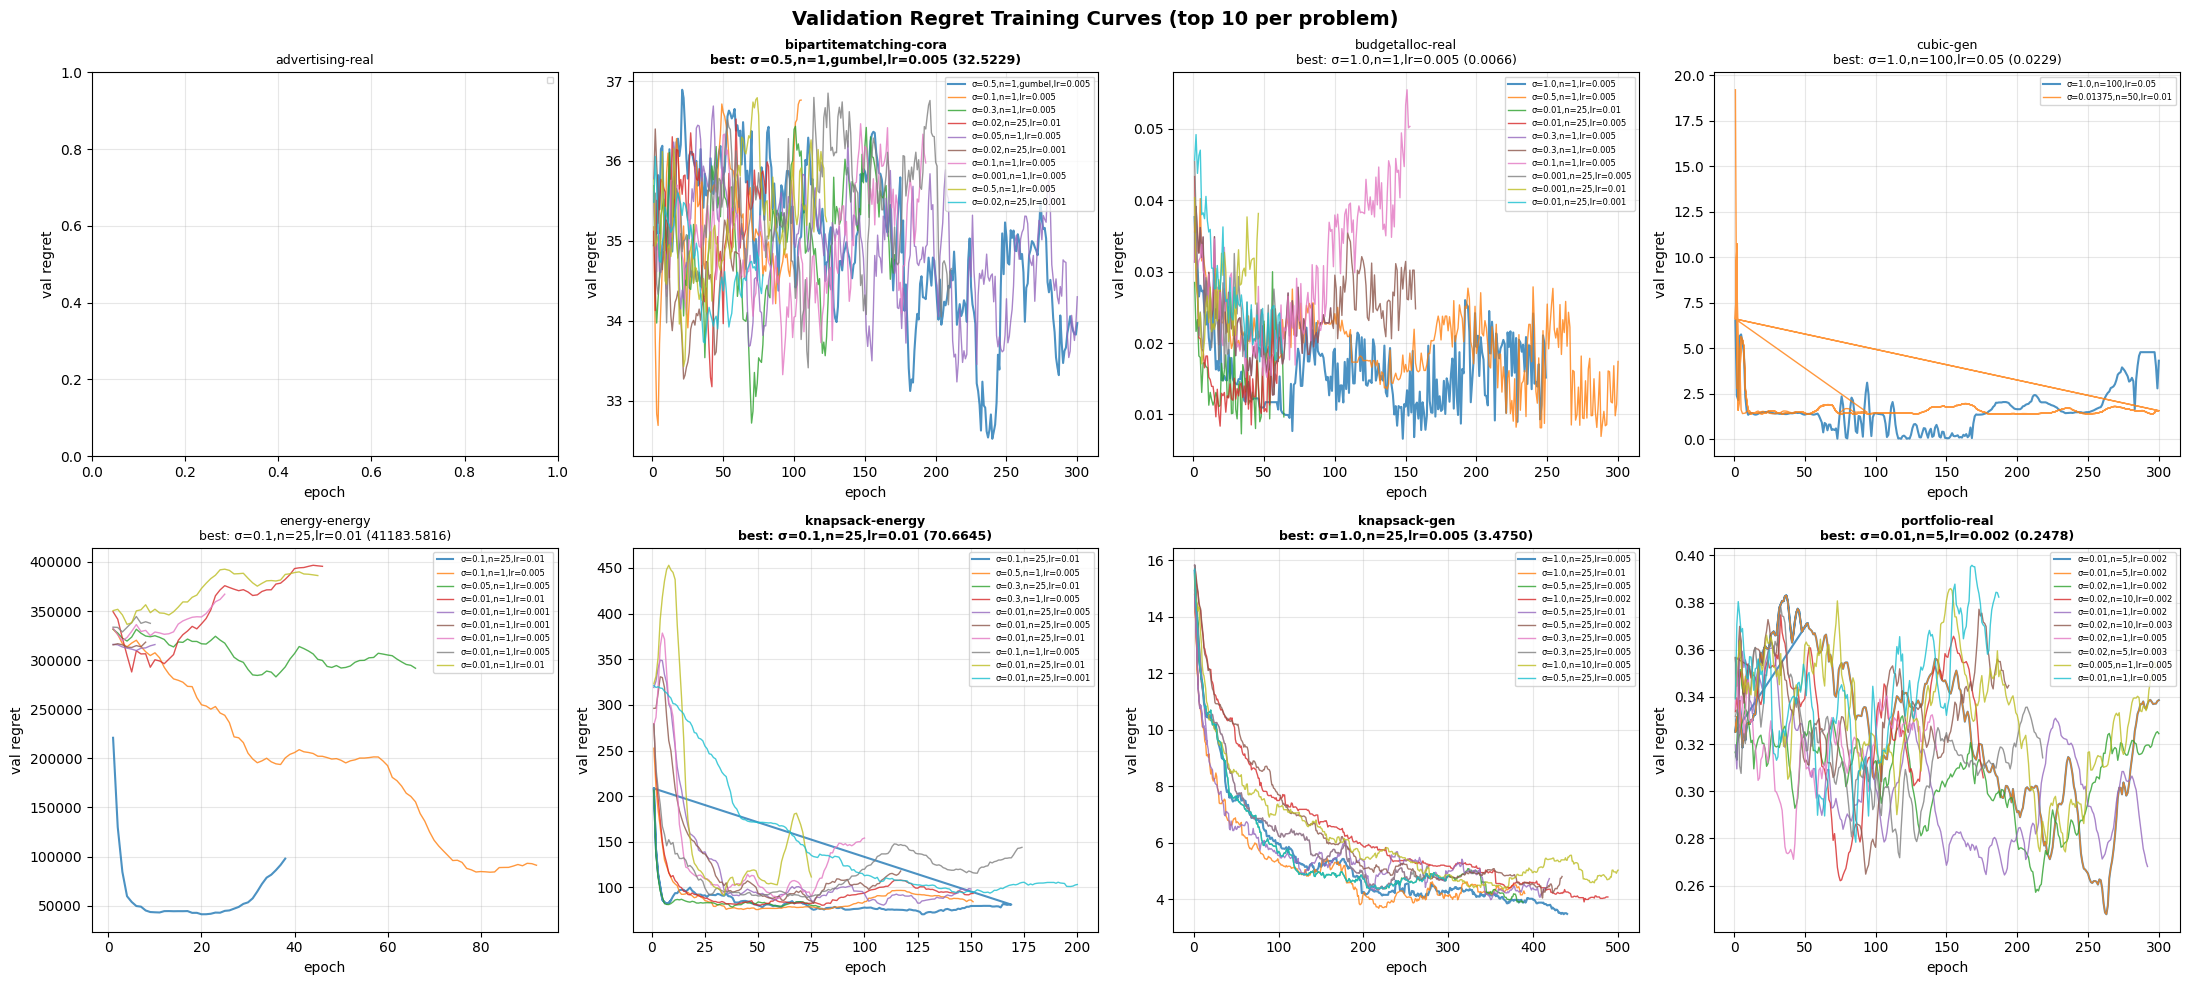

In [65]:
# Training curves for top-K experiments per problem, ranked by best val regret
K = 10  # number of best traces to display per problem

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for idx, data_name in enumerate(all_problems):
    if idx >= 8:
        break
    ax = axes_flat[idx]
    sub_logs = [lp for lp in all_logs if data_name in lp]
    
    # First pass: collect all traces with their best val regret
    traces = []
    for log_path in sub_logs:
        info = parse_log_file(log_path)
        if info is None or not info["epochs"]:
            continue
        
        epochs = [e["epoch"] for e in info["epochs"] if "val_regret" in e]
        val_regrets = [e["val_regret"] for e in info["epochs"] if "val_regret" in e]
        if not epochs:
            continue
        
        prefix = log_path.split("/")[3]
        sigma_val = info.get("cfg_sigma", "?")
        ns = info.get("cfg_n_samples", "?")
        noise = info.get("cfg_noise", "normal")
        lr = info.get("lr", None)
        label = f"σ={sigma_val},n={ns}"
        if noise != "normal":
            label += f",{noise}"
        if lr is not None:
            label += f",lr={lr}"
            #if lr > 0.001:
            #    continue
        
        best_val = min(val_regrets)
        traces.append((best_val, label, epochs, val_regrets))
    
    # Sort by best val regret and keep top K
    traces.sort(key=lambda t: t[0])
    top_traces = traces[:K]
    
    for rank, (best_val, label, epochs, val_regrets) in enumerate(top_traces):
        ax.plot(epochs, val_regrets, label=label, alpha=0.8, linewidth=1.5 if rank == 0 else 1.0)
    
    title = data_name
    if top_traces:
        best_label = top_traces[0][1]
        best_final_regret = top_traces[0][0]
        title += f"\nbest: {best_label} ({best_final_regret:.4f})"
    ax.set_xlabel("epoch")
    ax.set_ylabel("val regret")
    ax.set_title(title, fontweight="bold" if data_name in priority_problems else "normal", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, loc="upper right")

fig.suptitle(f"Validation Regret Training Curves (top {K} per problem)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Phase 1 SLURM Job Monitor

Parse SLURM output logs for Phase 1 experiments to check status and preliminary results.

In [66]:
# Monitor Phase 1 SLURM jobs
# The submission script uses "sweep_*" prefixes

phase1_prefixes = [
    # Phase 1A: sigma sweep (normal, n=1)
    "sweep_s001_n1", "sweep_s005_n1", "sweep_s01_n1", 
    "sweep_s03_n1", "sweep_s05_n1", "sweep_s1_n1",
    # Phase 1B: gumbel
    "sweep_s01_n1_gumbel", "sweep_s03_n1_gumbel", "sweep_s05_n1_gumbel",
    # Phase 1C: sigmoid
    "sweep_s01_n1_sigmoid", "sweep_s03_n1_sigmoid",
]

# Re-scan saved_records for Phase 1 results
phase1_logs = []
for prefix in phase1_prefixes:
    found = glob.glob(f"saved_records/*/perturb/{prefix}*/log.txt")
    phase1_logs.extend(found)

phase1_logs = sorted(set(phase1_logs))
print(f"Found {len(phase1_logs)} Phase 1 experiment logs")

if phase1_logs:
    ph1_records = []
    for lp in phase1_logs:
        parts = lp.split("/")
        dn = parts[1]
        pfx = parts[3]
        info = parse_log_file(lp)
        if info:
            status = info["status"]
            # Check SLURM err logs for preemption
            if status in ("unknown", "running"):
                preempted, job_id = check_preemption(dn, pfx)
                if preempted:
                    status = f"PREEMPTED (job {job_id})" if job_id else "PREEMPTED"
            
            ph1_records.append({
                "problem": dn,
                "config": pfx,
                "status": status,
                "epochs": len(info["epochs"]),
                "test_regret": info.get("test_regret", np.nan),
                "sigma": info.get("cfg_sigma", np.nan),
                "noise": info.get("cfg_noise", "normal"),
            })
    
    ph1_df = pd.DataFrame(ph1_records)
    print("\nPhase 1 Status:")
    print(ph1_df.to_string(index=False))
    
    # Summary
    n_done = (ph1_df['status'] == 'DONE').sum()
    n_running = (ph1_df['status'] == 'running').sum()
    n_preempted = ph1_df['status'].str.contains('PREEMPT', na=False).sum()
    n_unknown = (ph1_df['status'] == 'unknown').sum()
    print(f"\n  Completed:  {n_done} / {len(ph1_df)}")
    print(f"  Running:    {n_running}")
    print(f"  PREEMPTED:  {n_preempted}")
    print(f"  Unknown:    {n_unknown}")
    
    if n_preempted > 0:
        print("\n⚠ To resubmit preempted jobs, re-run the submission script.")
        print("  Completed results in saved_records/ will NOT be overwritten.")
else:
    print("No Phase 1 experiments found yet. Submit jobs first:")
    print("  bash shells/slurm/submit_phase1_sweep.sh")

Found 41 Phase 1 experiment logs



Phase 1 Status:
               problem               config                   status  epochs  test_regret  sigma  noise
bipartitematching-cora        sweep_s001_n1                     DONE     211      39.3147 0.0010 normal
bipartitematching-cora        sweep_s005_n1                     DONE     300      39.2959 0.0500 normal
bipartitematching-cora         sweep_s01_n1                     DONE     105      39.0634 0.1000 normal
bipartitematching-cora  sweep_s01_n1_gumbel                     DONE     113      38.0041 0.1000 gumbel
bipartitematching-cora sweep_s01_n1_sigmoid                     DONE     193      37.1202 0.1000 normal
bipartitematching-cora         sweep_s03_n1                     DONE     171      38.2459 0.3000 normal
bipartitematching-cora  sweep_s03_n1_gumbel                     DONE     196      38.4352 0.3000 gumbel
bipartitematching-cora sweep_s03_n1_sigmoid                     DONE     105      38.6619 0.3000 normal
bipartitematching-cora         sweep_s05_n1    

## 8. Phase 2 SLURM Job Monitor

Phase 2 scales n_samples and tests sigmoid activation on portfolio and knapsack.

- **2a**: Portfolio sigmoid (σ={0.005, 0.01, 0.02}, n={5,25}, lr={0.005, 0.01}) — 9 jobs
- **2b**: Portfolio n-scale (σ=0.1, n={5,25}) — 2 jobs
- **2c**: Knapsack n-scale (σ={0.2, 0.3, 0.5}, n={5,10,25}) — 9 jobs

In [67]:
# Monitor Phase 2 SLURM jobs
# Phase 2 uses "p2_*" prefixes

phase2_prefixes = [
    # Phase 2A: Portfolio sigmoid
    "p2_s0005_n5_sigmoid", "p2_s0005_n25_sigmoid",
    "p2_s001_n5_sigmoid",  "p2_s001_n25_sigmoid",
    "p2_s002_n5_sigmoid",  "p2_s002_n25_sigmoid",
    "p2_s0005_n25_sigmoid_lr01", "p2_s001_n25_sigmoid_lr01", "p2_s002_n25_sigmoid_lr01",
    # Phase 2B: Portfolio n-scale
    "p2_s01_n5", "p2_s01_n25",
    # Phase 2C: Knapsack n-scale
    "p2_s02_n5", "p2_s02_n10", "p2_s02_n25",
    "p2_s03_n5", "p2_s03_n10", "p2_s03_n25",
    "p2_s05_n5", "p2_s05_n10", "p2_s05_n25",
]

# Map prefixes to wave labels
def get_wave(pfx):
    if "sigmoid" in pfx:
        return "2a"
    elif pfx in ("p2_s01_n5", "p2_s01_n25"):
        return "2b"
    else:
        return "2c"

# Scan saved_records for Phase 2 results
phase2_logs = []
for prefix in phase2_prefixes:
    found = glob.glob(f"saved_records/*/perturb/{prefix}*/log.txt")
    phase2_logs.extend(found)

phase2_logs = sorted(set(phase2_logs))
print(f"Found {len(phase2_logs)} / 20 Phase 2 experiment logs\n")

# Baselines for comparison
TARGETS = {"portfolio-real": 0.24, "knapsack-gen": 3.0}
BASELINES_BEST = {"portfolio-real": 0.215, "knapsack-gen": 3.19}

if phase2_logs:
    ph2_records = []
    for lp in phase2_logs:
        parts = lp.split("/")
        dn = parts[1]
        pfx = parts[3]
        info = parse_log_file(lp)
        if info:
            status = info["status"]
            if status in ("unknown", "running"):
                preempted, job_id = check_preemption(dn, pfx)
                if preempted:
                    status = f"PREEMPTED (job {job_id})" if job_id else "PREEMPTED"

            ph2_records.append({
                "wave": get_wave(pfx),
                "problem": dn,
                "config": pfx,
                "status": status,
                "sigma": info.get("cfg_sigma", np.nan),
                "n_samples": info.get("cfg_n_samples", np.nan),
                "noise": info.get("cfg_noise", "normal"),
                "activation": info.get("cfg_output_activation", "none"),
                "lr": info.get("lr", np.nan),
                "epochs": len(info["epochs"]),
                "best_val_regret": min((e.get("val_regret", float("inf")) for e in info["epochs"]), default=np.nan),
                "test_regret": info.get("test_regret", np.nan),
            })

    ph2_df = pd.DataFrame(ph2_records).sort_values(["problem", "test_regret"], na_position="last")

    # Summary
    n_done = (ph2_df["status"] == "DONE").sum()
    n_running = (ph2_df["status"] == "running").sum()
    n_preempted = ph2_df["status"].str.contains("PREEMPT", na=False).sum()
    print(f"  Completed:  {n_done} / {len(ph2_df)}")
    print(f"  Running:    {n_running}")
    print(f"  PREEMPTED:  {n_preempted}")

    # Show results by problem
    for prob in ["portfolio-real", "knapsack-gen"]:
        sub = ph2_df[ph2_df["problem"] == prob].copy()
        if sub.empty:
            continue
        target = TARGETS.get(prob, np.nan)
        baseline = BASELINES_BEST.get(prob, np.nan)
        print(f"\n{'='*100}")
        print(f"  {prob}  |  target: {target}  |  best baseline: {baseline}")
        print(f"{'='*100}")
        cols = ["wave", "config", "status", "sigma", "n_samples", "activation", "lr",
                "epochs", "best_val_regret", "test_regret"]
        print(sub[cols].to_string(index=False))

        # Highlight configs that hit target
        hits = sub[sub["test_regret"] < target] if not np.isnan(target) else sub.iloc[0:0]
        if len(hits) > 0:
            print(f"\n  ✓ {len(hits)} config(s) below target {target}!")
        elif n_done > 0:
            best = sub["test_regret"].min()
            print(f"\n  Best so far: {best:.4f} (gap to target: {best - target:+.4f})")
else:
    print("No Phase 2 experiments found yet. Submit jobs:")
    print("  bash shells/slurm/submit_phase2_sweep.sh --dry-run")
    print("  bash shells/slurm/submit_phase2_sweep.sh")

Found 20 / 20 Phase 2 experiment logs

  Completed:  5 / 20
  Running:    0
  PREEMPTED:  15

  portfolio-real  |  target: 0.24  |  best baseline: 0.215
wave                    config                   status  sigma  n_samples activation     lr  epochs  best_val_regret  test_regret
  2b                p2_s01_n25                     DONE 0.1000         25       none 0.0050     300           0.2795       0.3136
  2a      p2_s0005_n25_sigmoid                     DONE 0.0050         25       none 0.0050     180           0.3139       0.3233
  2a       p2_s0005_n5_sigmoid                     DONE 0.0050          5       none 0.0050     175           0.3023       0.3520
  2a p2_s0005_n25_sigmoid_lr01 PREEMPTED (job 31416308) 0.0050         25       none 0.0100       5           0.3593          NaN
  2a       p2_s001_n25_sigmoid PREEMPTED (job 31416305) 0.0100         25       none 0.0050      14           0.3426          NaN
  2a  p2_s001_n25_sigmoid_lr01 PREEMPTED (job 31416309) 0.0100     

## 9. Phase 3 SLURM Job Monitor

Phase 3: LR grid search at good sigmas, low n. Dual-partition (preempt + hugheslab,gpu backup).

- **3a**: Portfolio sigmoid, n=1, σ={0.005,0.01,0.02} × lr={0.001,0.002,0.005,0.01,0.02,0.05} — 18 jobs
- **3b**: Portfolio sigmoid, n=5, σ=0.01 × lr={0.001,0.002,0.01,0.02,0.05} — 5 jobs
- **3c**: Portfolio normal, n=1, σ=0.1 × lr={0.001,0.002,0.01,0.02} — 4 jobs
- **3d**: Knapsack n=1, σ={0.3,0.5,1.0} × lr={0.001,0.002,0.005,0.01,0.02}, 500ep — 15 jobs
- **3e**: Knapsack n=5, σ={0.3,0.5} × lr={0.002,0.005,0.01}, 500ep — 6 jobs

Tracking 48 Phase 3 experiments

Found 48 / 48 Phase 3 experiment logs

  Completed:  48 / 48
  Running:    0
  PREEMPTED:  0

  portfolio-real  |  target: 0.24  |  best baseline: 0.215
wave                config status  sigma  n_samples activation     lr  epochs  best_val_regret  test_regret
  3a  p3_s002_n1_sig_lr002   DONE 0.0200          1    sigmoid 0.0020     308           0.2572       0.2777
  3a   p3_s002_n1_sig_lr05   DONE 0.0200          1    sigmoid 0.0500     122           0.2871       0.2903
  3a  p3_s001_n1_sig_lr002   DONE 0.0100          1    sigmoid 0.0020     292           0.2645       0.2917
  3a  p3_s0005_n1_sig_lr02   DONE 0.0050          1    sigmoid 0.0200     300           0.2954       0.2970
  3a  p3_s002_n1_sig_lr001   DONE 0.0200          1    sigmoid 0.0010     300           0.2873       0.2970
  3a  p3_s001_n1_sig_lr005   DONE 0.0100          1    sigmoid 0.0050     187           0.2784       0.3003
  3a  p3_s002_n1_sig_lr005   DONE 0.0200          1    sig

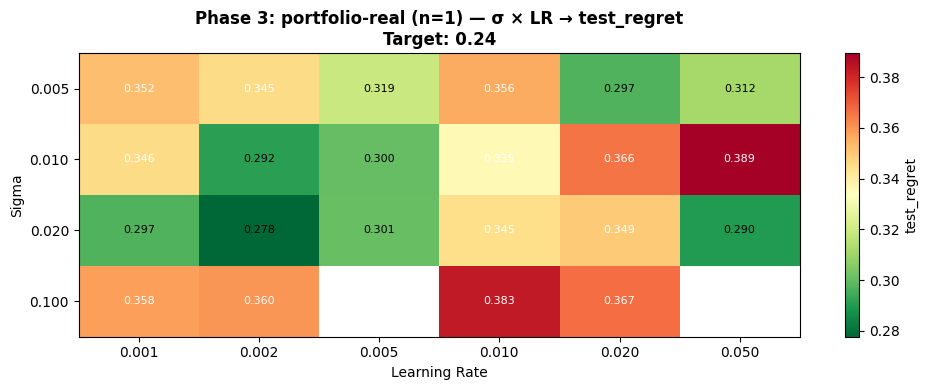

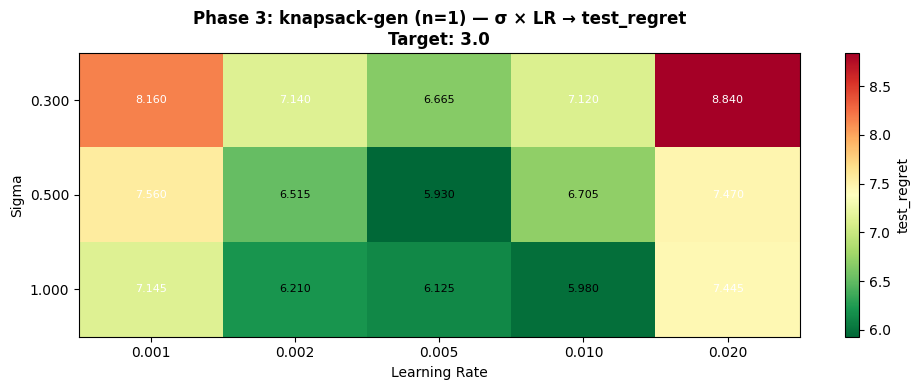

In [68]:
# ── Phase 3 Monitor ──
# Phase 3 prefixes all start with "p3_"

phase3_prefixes = []

# 3a: Portfolio sigmoid n=1 LR grid
for sigma_tag in ["s0005", "s001", "s002"]:
    for lr_tag in ["lr001", "lr002", "lr005", "lr01", "lr02", "lr05"]:
        phase3_prefixes.append(f"p3_{sigma_tag}_n1_sig_{lr_tag}")

# 3b: Portfolio sigmoid n=5 σ=0.01 LR grid
for lr_tag in ["lr001", "lr002", "lr01", "lr02", "lr05"]:
    phase3_prefixes.append(f"p3_s001_n5_sig_{lr_tag}")

# 3c: Portfolio normal n=1 σ=0.1 LR grid
for lr_tag in ["lr001", "lr002", "lr01", "lr02"]:
    phase3_prefixes.append(f"p3_s01_n1_{lr_tag}")

# 3d: Knapsack n=1 LR grid
for sigma_tag in ["s03", "s05", "s1"]:
    for lr_tag in ["lr001", "lr002", "lr005", "lr01", "lr02"]:
        phase3_prefixes.append(f"p3_{sigma_tag}_n1_{lr_tag}")

# 3e: Knapsack n=5 LR grid
for sigma_tag in ["s03", "s05"]:
    for lr_tag in ["lr002", "lr005", "lr01"]:
        phase3_prefixes.append(f"p3_{sigma_tag}_n5_{lr_tag}")

print(f"Tracking {len(phase3_prefixes)} Phase 3 experiments\n")

# Define which problems each prefix maps to
def get_p3_problem(pfx):
    if "sig" in pfx or "s01_n1" in pfx:
        return "portfolio-real"
    else:
        return "knapsack-gen"

def get_p3_wave(pfx):
    if "sig" in pfx and "n1" in pfx:
        return "3a"
    elif "sig" in pfx and "n5" in pfx:
        return "3b"
    elif "s01_n1" in pfx:
        return "3c"
    elif "n1" in pfx:
        return "3d"
    else:
        return "3e"

# Scan saved_records for Phase 3 results
phase3_logs = []
for prefix in phase3_prefixes:
    found = glob.glob(f"saved_records/*/perturb/{prefix}*/log.txt")
    phase3_logs.extend(found)

phase3_logs = sorted(set(phase3_logs))
print(f"Found {len(phase3_logs)} / {len(phase3_prefixes)} Phase 3 experiment logs\n")

TARGETS = {"portfolio-real": 0.24, "knapsack-gen": 3.0}
BASELINES_BEST = {"portfolio-real": 0.215, "knapsack-gen": 3.19}

if phase3_logs:
    ph3_records = []
    for lp in phase3_logs:
        parts = lp.split("/")
        dn = parts[1]
        pfx = parts[3]
        info = parse_log_file(lp)
        if info:
            status = info["status"]
            if status in ("unknown", "running"):
                preempted, job_id = check_preemption(dn, pfx)
                if preempted:
                    status = f"PREEMPTED"

            # Extract lr from prefix
            lr_m = re.search(r'lr(\d+)', pfx)
            lr_val = info.get("lr", np.nan)

            ph3_records.append({
                "wave": get_p3_wave(pfx),
                "problem": dn,
                "config": pfx,
                "status": status,
                "sigma": info.get("cfg_sigma", np.nan),
                "n_samples": info.get("cfg_n_samples", np.nan),
                "activation": "sigmoid" if "sig" in pfx else "none",
                "lr": lr_val,
                "epochs": len(info["epochs"]),
                "best_val_regret": min((e.get("val_regret", float("inf")) for e in info["epochs"]), default=np.nan),
                "test_regret": info.get("test_regret", np.nan),
            })

    ph3_df = pd.DataFrame(ph3_records).sort_values(["problem", "test_regret", "best_val_regret"], na_position="last")

    n_done = (ph3_df["status"] == "DONE").sum()
    n_running = (ph3_df["status"] == "running").sum()
    n_preempted = ph3_df["status"].str.contains("PREEMPT", na=False).sum()
    print(f"  Completed:  {n_done} / {len(ph3_df)}")
    print(f"  Running:    {n_running}")
    print(f"  PREEMPTED:  {n_preempted}")

    # Show per-problem results  
    for prob in ["portfolio-real", "knapsack-gen"]:
        sub = ph3_df[ph3_df["problem"] == prob].copy()
        if sub.empty:
            continue
        target = TARGETS.get(prob, np.nan)
        baseline = BASELINES_BEST.get(prob, np.nan)
        print(f"\n{'='*120}")
        print(f"  {prob}  |  target: {target}  |  best baseline: {baseline}")
        print(f"{'='*120}")
        cols = ["wave", "config", "status", "sigma", "n_samples", "activation", "lr",
                "epochs", "best_val_regret", "test_regret"]
        print(sub[cols].to_string(index=False))

        hits = sub[sub["test_regret"] < target] if not np.isnan(target) else sub.iloc[0:0]
        if len(hits) > 0:
            print(f"\n  ✓ {len(hits)} config(s) below target {target}!")
            print(hits[["config", "test_regret", "sigma", "lr"]].to_string(index=False))
        else:
            done_sub = sub[sub["status"] == "DONE"]
            if not done_sub.empty:
                best = done_sub["test_regret"].min()
                print(f"\n  Best completed: {best:.4f} (gap to target: {best - target:+.4f})")
            running_sub = sub[sub["status"] == "running"]
            if not running_sub.empty:
                best_val = running_sub["best_val_regret"].min()
                print(f"  Best running val_regret: {best_val:.4f}")

    # ── LR heatmap: sigma × lr → best_val_regret ──
    for prob in ["portfolio-real", "knapsack-gen"]:
        sub = ph3_df[ph3_df["problem"] == prob].copy()
        if sub.empty or len(sub) < 3:
            continue
        sub_n1 = sub[sub["n_samples"] == 1].copy()
        if sub_n1.empty:
            continue
        
        metric_col = "test_regret" if (sub_n1["status"] == "DONE").sum() > 3 else "best_val_regret"
        pivot = sub_n1.pivot_table(index="sigma", columns="lr", values=metric_col, aggfunc="min")
        
        if pivot.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(10, 4))
        im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{x:.3f}" for x in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{y:.3f}" for y in pivot.index])
        ax.set_xlabel("Learning Rate")
        ax.set_ylabel("Sigma")
        
        # Annotate cells
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                           color="white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black")
        
        target = TARGETS.get(prob, np.nan)
        plt.colorbar(im, ax=ax, label=metric_col)
        ax.set_title(f"Phase 3: {prob} (n=1) — σ × LR → {metric_col}\nTarget: {target}", fontweight="bold")
        plt.tight_layout()
        plt.show()

else:
    print("No Phase 3 experiments found yet. Submit jobs:")
    print("  bash shells/slurm/submit_phase3_sweep.sh --dry-run")
    print("  bash shells/slurm/submit_phase3_sweep.sh")

## 10. Phase 4 SLURM Job Monitor

Phase 4: Scale n_samples at Phase 3 winners. Dual-partition (preempt + hugheslab,gpu backup).

- **4a**: Portfolio σ=0.02, sigmoid, lr=0.002, n={5,10,25} — 3 jobs
- **4b**: Portfolio σ=0.02, sigmoid, lr={0.001,0.003}, n={5,10} — 4 jobs
- **4c**: Portfolio σ=0.01, sigmoid, lr=0.002, n={5,10} — 2 jobs
- **4d**: Portfolio σ=0.005, sigmoid, lr=0.02, n={5,10} — 2 jobs
- **4e**: Knapsack σ=0.5, n={10,25}, lr={0.002,0.005,0.01}, 500ep — 6 jobs
- **4f**: Knapsack σ=1.0, n={10,25}, lr={0.002,0.005,0.01}, 500ep — 6 jobs
- **4g**: Knapsack σ=0.3, n={10,25}, lr={0.002,0.005}, 500ep — 4 jobs

Tracking 27 Phase 4 experiments

Found 27 / 27 Phase 4 experiment logs

  Completed:  19 / 27
  Running:    2
  PREEMPTED:  6

  portfolio-real  |  target: 0.24  |  best baseline: 0.215
wave                config status  sigma  n_samples activation     lr  epochs  best_val_regret  test_regret
  4b  p4_s002_n5_sig_lr001   DONE 0.0200          5    sigmoid 0.0010     300           0.2787       0.2845
  4b p4_s002_n10_sig_lr003   DONE 0.0200         10    sigmoid 0.0030     205           0.2649       0.3014
  4b  p4_s002_n5_sig_lr003   DONE 0.0200          5    sigmoid 0.0030     218           0.2718       0.3092
  4a p4_s002_n10_sig_lr002   DONE 0.0200         10    sigmoid 0.0020     176           0.2621       0.3125
  4c  p4_s001_n5_sig_lr002   DONE 0.0100          5    sigmoid 0.0020     305           0.2478       0.3137
  4b p4_s002_n10_sig_lr001   DONE 0.0200         10    sigmoid 0.0010     199           0.3166       0.3138
  4c p4_s001_n10_sig_lr002   DONE 0.0100         10    sig

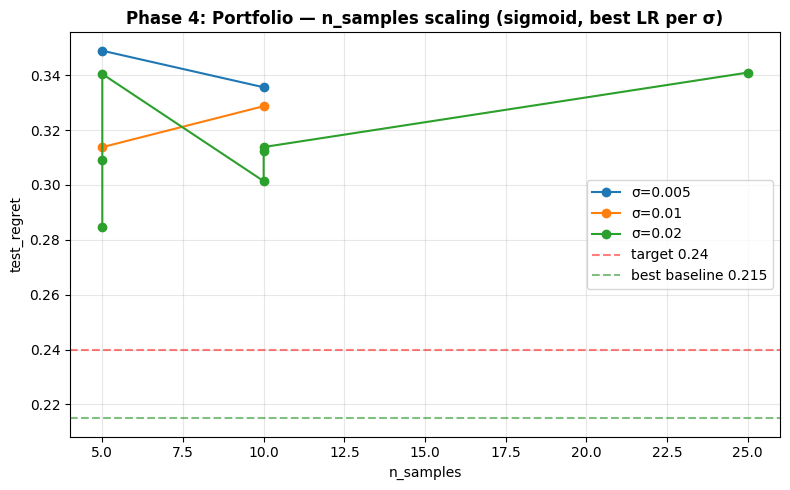

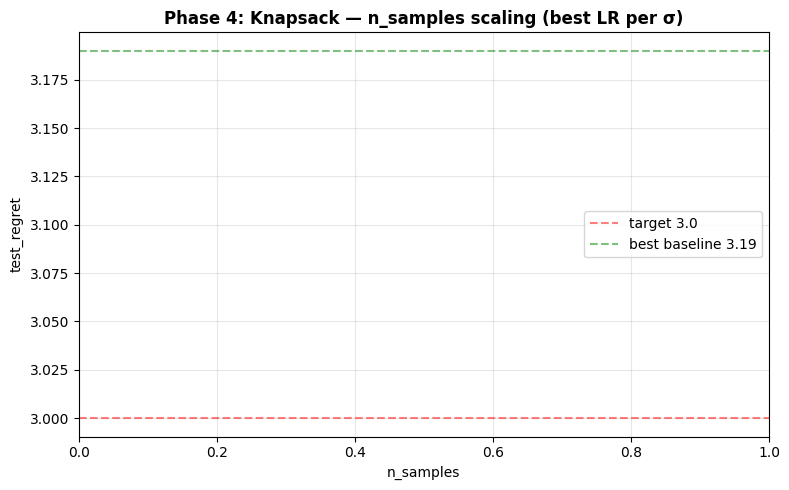

In [69]:
# ── Phase 4 Monitor ──
# Phase 4 prefixes all start with "p4_"

phase4_prefixes = []

# 4a: Portfolio σ=0.02 sigmoid lr=0.002, n={5,10,25}
for ns in [5, 10, 25]:
    phase4_prefixes.append(f"p4_s002_n{ns}_sig_lr002")

# 4b: Portfolio σ=0.02 sigmoid lr fine-tune, n={5,10}
for ns in [5, 10]:
    for lr_tag in ["lr001", "lr003"]:
        phase4_prefixes.append(f"p4_s002_n{ns}_sig_{lr_tag}")

# 4c: Portfolio σ=0.01 sigmoid lr=0.002, n={5,10}
for ns in [5, 10]:
    phase4_prefixes.append(f"p4_s001_n{ns}_sig_lr002")

# 4d: Portfolio σ=0.005 sigmoid lr=0.02, n={5,10}
for ns in [5, 10]:
    phase4_prefixes.append(f"p4_s0005_n{ns}_sig_lr02")

# 4e: Knapsack σ=0.5, n={10,25}
for ns in [10, 25]:
    for lr_tag in ["lr002", "lr005", "lr01"]:
        phase4_prefixes.append(f"p4_s05_n{ns}_{lr_tag}")

# 4f: Knapsack σ=1.0, n={10,25}
for ns in [10, 25]:
    for lr_tag in ["lr002", "lr005", "lr01"]:
        phase4_prefixes.append(f"p4_s1_n{ns}_{lr_tag}")

# 4g: Knapsack σ=0.3, n={10,25}
for ns in [10, 25]:
    for lr_tag in ["lr002", "lr005"]:
        phase4_prefixes.append(f"p4_s03_n{ns}_{lr_tag}")

print(f"Tracking {len(phase4_prefixes)} Phase 4 experiments\n")

def get_p4_wave(pfx):
    if "s002" in pfx and "lr002" in pfx and "sig" in pfx:
        return "4a"
    elif "s002" in pfx and "sig" in pfx:
        return "4b"
    elif "s001" in pfx and "sig" in pfx:
        return "4c"
    elif "s0005" in pfx and "sig" in pfx:
        return "4d"
    elif "s05_n" in pfx:
        return "4e"
    elif "s1_n" in pfx:
        return "4f"
    else:
        return "4g"

def get_p4_problem(pfx):
    if "sig" in pfx:
        return "portfolio-real"
    else:
        return "knapsack-gen"

# Scan saved_records
phase4_logs = []
for prefix in phase4_prefixes:
    found = glob.glob(f"saved_records/*/perturb/{prefix}*/log.txt")
    phase4_logs.extend(found)

phase4_logs = sorted(set(phase4_logs))
print(f"Found {len(phase4_logs)} / {len(phase4_prefixes)} Phase 4 experiment logs\n")

TARGETS = {"portfolio-real": 0.24, "knapsack-gen": 3.0}
BASELINES_BEST = {"portfolio-real": 0.215, "knapsack-gen": 3.19}

if phase4_logs:
    ph4_records = []
    for lp in phase4_logs:
        parts = lp.split("/")
        dn = parts[1]
        pfx = parts[3]
        info = parse_log_file(lp)
        if info:
            status = info["status"]
            if status in ("unknown", "running"):
                preempted, job_id = check_preemption(dn, pfx)
                if preempted:
                    status = "PREEMPTED"

            ph4_records.append({
                "wave": get_p4_wave(pfx),
                "problem": dn,
                "config": pfx,
                "status": status,
                "sigma": info.get("cfg_sigma", np.nan),
                "n_samples": info.get("cfg_n_samples", np.nan),
                "activation": "sigmoid" if "sig" in pfx else "none",
                "lr": info.get("lr", np.nan),
                "epochs": len(info["epochs"]),
                "best_val_regret": min((e.get("val_regret", float("inf")) for e in info["epochs"]), default=np.nan),
                "test_regret": info.get("test_regret", np.nan),
            })

    ph4_df = pd.DataFrame(ph4_records).sort_values(["problem", "test_regret", "best_val_regret"], na_position="last")

    n_done = (ph4_df["status"] == "DONE").sum()
    n_running = (ph4_df["status"] == "running").sum()
    n_preempted = ph4_df["status"].str.contains("PREEMPT", na=False).sum()
    print(f"  Completed:  {n_done} / {len(ph4_df)}")
    print(f"  Running:    {n_running}")
    print(f"  PREEMPTED:  {n_preempted}")

    for prob in ["portfolio-real", "knapsack-gen"]:
        sub = ph4_df[ph4_df["problem"] == prob].copy()
        if sub.empty:
            continue
        target = TARGETS.get(prob, np.nan)
        baseline = BASELINES_BEST.get(prob, np.nan)
        print(f"\n{'='*120}")
        print(f"  {prob}  |  target: {target}  |  best baseline: {baseline}")
        print(f"{'='*120}")
        cols = ["wave", "config", "status", "sigma", "n_samples", "activation", "lr",
                "epochs", "best_val_regret", "test_regret"]
        print(sub[cols].to_string(index=False))

        hits = sub[sub["test_regret"] < target] if not np.isnan(target) else sub.iloc[0:0]
        if len(hits) > 0:
            print(f"\n  ✓ {len(hits)} config(s) BELOW TARGET {target}!")
            print(hits[["config", "test_regret", "sigma", "n_samples", "lr"]].to_string(index=False))
        else:
            done_sub = sub[sub["status"] == "DONE"]
            if not done_sub.empty:
                best = done_sub["test_regret"].min()
                print(f"\n  Best completed: {best:.4f} (gap to target: {best - target:+.4f})")
            running_sub = sub[sub["status"] == "running"]
            if not running_sub.empty:
                best_val = running_sub["best_val_regret"].min()
                print(f"  Best running val_regret: {best_val:.4f}")

    # ── n_samples scaling plot for portfolio ──
    port_sub = ph4_df[ph4_df["problem"] == "portfolio-real"].copy()
    if not port_sub.empty and (port_sub["status"] == "DONE").sum() >= 2:
        metric = "test_regret"
        fig, ax = plt.subplots(figsize=(8, 5))
        for sigma in sorted(port_sub["sigma"].unique()):
            ss = port_sub[(port_sub["sigma"] == sigma) & (port_sub["status"] == "DONE")].sort_values("n_samples")
            if len(ss) >= 2:
                ax.plot(ss["n_samples"], ss[metric], "o-", label=f"σ={sigma}")
        ax.axhline(y=0.24, color="red", linestyle="--", alpha=0.5, label="target 0.24")
        ax.axhline(y=0.215, color="green", linestyle="--", alpha=0.5, label="best baseline 0.215")
        ax.set_xlabel("n_samples")
        ax.set_ylabel(metric)
        ax.set_title("Phase 4: Portfolio — n_samples scaling (sigmoid, best LR per σ)", fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ── n_samples scaling plot for knapsack ──
    knap_sub = ph4_df[ph4_df["problem"] == "knapsack-gen"].copy()
    if not knap_sub.empty and (knap_sub["status"] == "DONE").sum() >= 2:
        metric = "test_regret"
        fig, ax = plt.subplots(figsize=(8, 5))
        for sigma in sorted(knap_sub["sigma"].unique()):
            ss = knap_sub[(knap_sub["sigma"] == sigma) & (knap_sub["status"] == "DONE")]
            best_per_n = ss.groupby("n_samples")[metric].min().reset_index().sort_values("n_samples")
            if len(best_per_n) >= 2:
                ax.plot(best_per_n["n_samples"], best_per_n[metric], "o-", label=f"σ={sigma}")
        ax.axhline(y=3.0, color="red", linestyle="--", alpha=0.5, label="target 3.0")
        ax.axhline(y=3.19, color="green", linestyle="--", alpha=0.5, label="best baseline 3.19")
        ax.set_xlabel("n_samples")
        ax.set_ylabel(metric)
        ax.set_title("Phase 4: Knapsack — n_samples scaling (best LR per σ)", fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

else:
    print("No Phase 4 experiments found yet. Submit jobs:")
    print("  bash shells/slurm/submit_phase4_sweep.sh --dry-run")
    print("  bash shells/slurm/submit_phase4_sweep.sh")

## 11. Phase 5 SLURM Job Monitor

Phase 5: Sigma decay + softplus + low-LR portfolio. Dual-partition (preempt + hugheslab,gpu backup).

**Knapsack** (σ=0.5, n=5, 500ep, patience=200):
- **5a**: Baseline (no activation) × lr={0.05,0.02,0.01,0.005} — 4 jobs
- **5b**: Softplus activation × lr={0.05,0.02,0.01,0.005} — 4 jobs
- **5c**: Linear decay σ 0.5→0.05, warmup=100 × lr={0.05,0.02,0.01,0.005} — 4 jobs
- **5d**: Decay + softplus × lr={0.02,0.01,0.005} — 3 jobs

**Portfolio** (no activation, 300ep, patience=100):
- **5e**: σ=0.5, lr=5e-4, n={1,5} — 2 jobs
- **5f**: σ=0.01, lr=5e-4, n={1,5} — 2 jobs

Tracking 19 Phase 5 experiments

Found 19 / 19 Phase 5 experiment logs

  Completed:  13 / 19
  Running:    6
  PREEMPTED:  0

  knapsack-gen  |  target: 3.0  |  best baseline: 3.19
wave                   config      condition  status  sigma  n_samples     lr  epochs  best_val_regret  test_regret
  5a          p5_s05_n5_lr005       baseline    DONE 0.5000          5 0.0050     500           5.7125       4.8500
  5c    p5_s05_n5_decay_lr005          decay    DONE 0.5000          5 0.0050     466           6.0375       5.7950
  5c     p5_s05_n5_decay_lr01          decay    DONE 0.5000          5 0.0100     298           6.3875       6.2200
  5a           p5_s05_n5_lr01       baseline    DONE 0.5000          5 0.0100     298           6.3875       6.2200
  5d  p5_s05_n5_decay_sp_lr02 decay+softplus    DONE 0.5000          5 0.0200     318           7.0375       6.2900
  5c     p5_s05_n5_decay_lr02          decay    DONE 0.5000          5 0.0200     290           7.0000       6.3100
  5a  

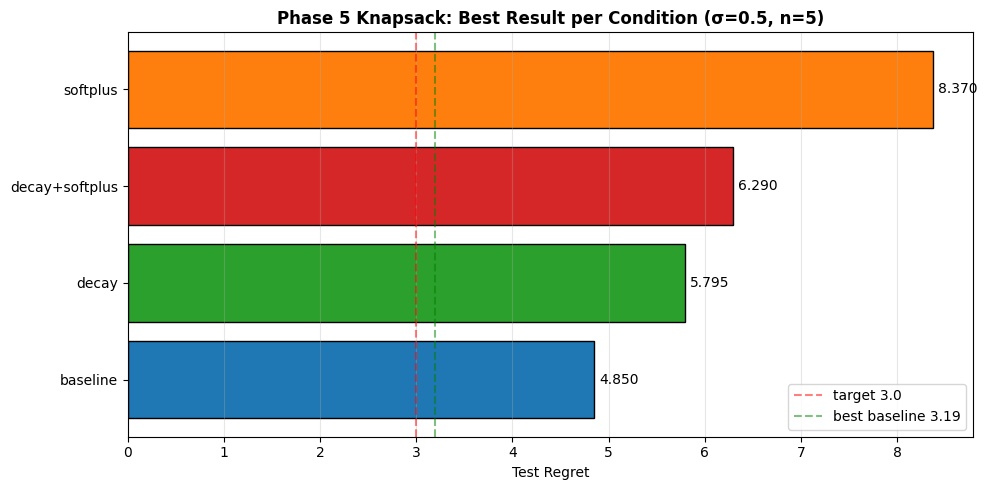

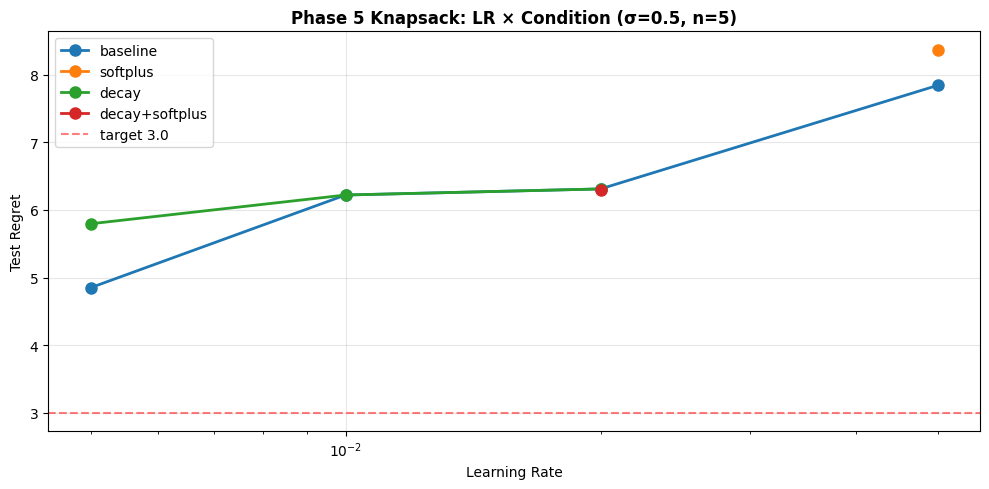

In [70]:
# ── Phase 5 Monitor ──
# Phase 5 prefixes all start with "p5_"

phase5_prefixes = []

# 5a: Knapsack baseline σ=0.5, n=5
for lr_tag in ["lr05", "lr02", "lr01", "lr005"]:
    phase5_prefixes.append(f"p5_s05_n5_{lr_tag}")

# 5b: Knapsack softplus σ=0.5, n=5
for lr_tag in ["lr05", "lr02", "lr01", "lr005"]:
    phase5_prefixes.append(f"p5_s05_n5_sp_{lr_tag}")

# 5c: Knapsack linear decay σ 0.5→0.05, warmup=100, n=5
for lr_tag in ["lr05", "lr02", "lr01", "lr005"]:
    phase5_prefixes.append(f"p5_s05_n5_decay_{lr_tag}")

# 5d: Knapsack decay + softplus
for lr_tag in ["lr02", "lr01", "lr005"]:
    phase5_prefixes.append(f"p5_s05_n5_decay_sp_{lr_tag}")

# 5e: Portfolio σ=0.5, lr=5e-4
for ns in [1, 5]:
    phase5_prefixes.append(f"p5_s05_n{ns}_lr0005")

# 5f: Portfolio σ=0.01, lr=5e-4
for ns in [1, 5]:
    phase5_prefixes.append(f"p5_s001_n{ns}_lr0005")

print(f"Tracking {len(phase5_prefixes)} Phase 5 experiments\n")

def get_p5_wave(pfx):
    if "decay_sp_" in pfx:      return "5d"
    elif "decay_" in pfx:        return "5c"
    elif "_sp_" in pfx:          return "5b"
    elif "s05_n5_lr" in pfx:     return "5a"
    elif "s05_n" in pfx:         return "5e"
    elif "s001_n" in pfx:        return "5f"
    else:                        return "5?"

def get_p5_problem(pfx):
    if pfx.startswith("p5_s001_") or "lr0005" in pfx and "s05_n1" in pfx or "s05_n5_lr0005" == pfx.replace("p5_",""):
        # Portfolio: 5e and 5f
        pass
    # Simpler: 5a-5d are knapsack, 5e-5f are portfolio
    w = get_p5_wave(pfx)
    return "portfolio-real" if w in ("5e", "5f") else "knapsack-gen"

def get_p5_condition(pfx):
    """Return human-readable condition label."""
    if "decay_sp_" in pfx:   return "decay+softplus"
    elif "decay_" in pfx:     return "decay"
    elif "_sp_" in pfx:       return "softplus"
    else:                     return "baseline"

# Scan saved_records
phase5_logs = []
for prefix in phase5_prefixes:
    found = glob.glob(f"saved_records/*/perturb/{prefix}*/log.txt")
    phase5_logs.extend(found)

phase5_logs = sorted(set(phase5_logs))
print(f"Found {len(phase5_logs)} / {len(phase5_prefixes)} Phase 5 experiment logs\n")

TARGETS = {"portfolio-real": 0.24, "knapsack-gen": 3.0}
BASELINES_BEST = {"portfolio-real": 0.215, "knapsack-gen": 3.19}

if phase5_logs:
    ph5_records = []
    for lp in phase5_logs:
        parts = lp.split("/")
        dn = parts[1]
        pfx = parts[3]
        info = parse_log_file(lp)
        if info:
            status = info["status"]
            if status in ("unknown", "running"):
                preempted, job_id = check_preemption(dn, pfx)
                if preempted:
                    status = "PREEMPTED"

            ph5_records.append({
                "wave": get_p5_wave(pfx),
                "problem": dn,
                "config": pfx,
                "condition": get_p5_condition(pfx),
                "status": status,
                "sigma": info.get("cfg_sigma", np.nan),
                "n_samples": info.get("cfg_n_samples", np.nan),
                "lr": info.get("lr", np.nan),
                "epochs": len(info["epochs"]),
                "best_val_regret": min((e.get("val_regret", float("inf")) for e in info["epochs"]), default=np.nan),
                "test_regret": info.get("test_regret", np.nan),
            })

    ph5_df = pd.DataFrame(ph5_records).sort_values(["problem", "test_regret", "best_val_regret"], na_position="last")

    n_done = (ph5_df["status"] == "DONE").sum()
    n_running = (ph5_df["status"] == "running").sum()
    n_preempted = ph5_df["status"].str.contains("PREEMPT", na=False).sum()
    print(f"  Completed:  {n_done} / {len(ph5_df)}")
    print(f"  Running:    {n_running}")
    print(f"  PREEMPTED:  {n_preempted}")

    for prob in ["knapsack-gen", "portfolio-real"]:
        sub = ph5_df[ph5_df["problem"] == prob].copy()
        if sub.empty:
            continue
        target = TARGETS.get(prob, np.nan)
        baseline = BASELINES_BEST.get(prob, np.nan)
        print(f"\n{'='*120}")
        print(f"  {prob}  |  target: {target}  |  best baseline: {baseline}")
        print(f"{'='*120}")
        cols = ["wave", "config", "condition", "status", "sigma", "n_samples", "lr",
                "epochs", "best_val_regret", "test_regret"]
        print(sub[cols].to_string(index=False))

        hits = sub[sub["test_regret"] < target] if not np.isnan(target) else sub.iloc[0:0]
        if len(hits) > 0:
            print(f"\n  ✓ {len(hits)} config(s) BELOW TARGET {target}!")
            print(hits[["config", "condition", "test_regret", "lr"]].to_string(index=False))
        else:
            done_sub = sub[sub["status"] == "DONE"]
            if not done_sub.empty:
                best = done_sub["test_regret"].min()
                print(f"\n  Best completed: {best:.4f} (gap to target: {best - target:+.4f})")
            running_sub = sub[sub["status"] == "running"]
            if not running_sub.empty:
                best_val = running_sub["best_val_regret"].min()
                print(f"  Best running val_regret: {best_val:.4f}")

    # ── Knapsack: condition comparison bar chart ──
    knap_sub = ph5_df[ph5_df["problem"] == "knapsack-gen"].copy()
    done_knap = knap_sub[knap_sub["status"] == "DONE"]
    if len(done_knap) >= 3:
        fig, ax = plt.subplots(figsize=(10, 5))

        # Best test_regret per condition
        best_per_cond = done_knap.groupby("condition")["test_regret"].min().sort_values()
        colors = {"baseline": "tab:blue", "softplus": "tab:orange",
                  "decay": "tab:green", "decay+softplus": "tab:red"}
        bar_colors = [colors.get(c, "tab:gray") for c in best_per_cond.index]

        bars = ax.barh(best_per_cond.index, best_per_cond.values, color=bar_colors, edgecolor="black")
        ax.axvline(x=3.0, color="red", linestyle="--", alpha=0.5, label="target 3.0")
        ax.axvline(x=3.19, color="green", linestyle="--", alpha=0.5, label="best baseline 3.19")

        for bar, val in zip(bars, best_per_cond.values):
            ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
                    va="center", fontsize=10)

        ax.set_xlabel("Test Regret")
        ax.set_title("Phase 5 Knapsack: Best Result per Condition (σ=0.5, n=5)", fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()

        # LR comparison grouped by condition
        fig, ax = plt.subplots(figsize=(10, 5))
        for cond in ["baseline", "softplus", "decay", "decay+softplus"]:
            cs = done_knap[done_knap["condition"] == cond].sort_values("lr")
            if not cs.empty:
                ax.plot(cs["lr"], cs["test_regret"], "o-", label=cond, linewidth=2, markersize=8)
        ax.axhline(y=3.0, color="red", linestyle="--", alpha=0.5, label="target 3.0")
        ax.set_xscale("log")
        ax.set_xlabel("Learning Rate")
        ax.set_ylabel("Test Regret")
        ax.set_title("Phase 5 Knapsack: LR × Condition (σ=0.5, n=5)", fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

else:
    print("No Phase 5 experiments found yet. Submit jobs:")
    print("  bash shells/slurm/submit_phase5_sweep.sh --dry-run")
    print("  bash shells/slurm/submit_phase5_sweep.sh")

Knapsack W3: 8 experiments registered
Knapsack Wave 3 — Status
Prefix                                     Status       Epochs   BestVal   
--------------------------------------------------------------------------------
  sd1_kn_w3_se005_w50_lr1e3                PENDING     
  sd1_kn_w3_se005_w50_lr5e3                PENDING     
  sd1_kn_w3_se005_w100_lr1e3               PENDING     
  sd1_kn_w3_se005_w100_lr5e3               PENDING     
  sd1_kn_w3_se001_w50_lr1e3                PENDING     
  sd1_kn_w3_se001_w50_lr5e3                PENDING     
  sd1_kn_w3_se001_w100_lr1e3               PENDING     
  sd1_kn_w3_se001_w100_lr5e3               PENDING     
--------------------------------------------------------------------------------
W1 best (sd1_s05_lr5e3, n=25): regret = 3.580
W2 best (sd1_kn_n5_s10_plw0_lr5e3, n=5): regret = 4.140


FileNotFoundError: [Errno 2] No such file or directory: 'saved_records/knapsack-gen/perturb/sd1_s05_lr5e3/val_logs.csv'

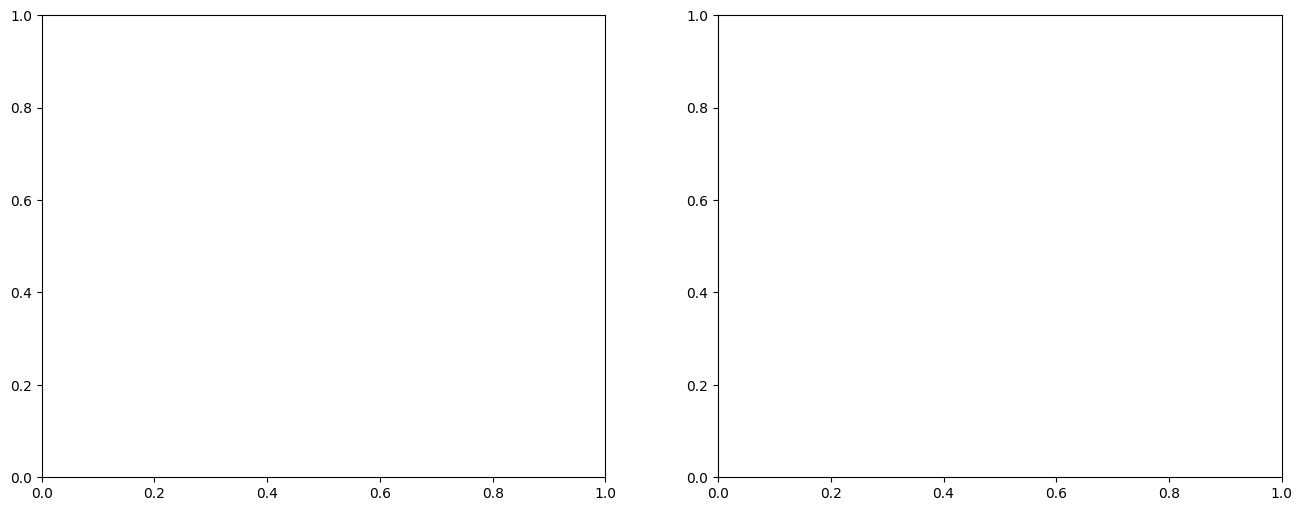

In [1]:
# ── Knapsack Wave 3: Registry ──────────────────────────────────────
KN_W3 = {
    # σ_end=0.05, warmup=50
    "sd1_kn_w3_se005_w50_lr1e3":  dict(se=0.05, warmup=50, lr=1e-3),
    "sd1_kn_w3_se005_w50_lr5e3":  dict(se=0.05, warmup=50, lr=5e-3),
    # σ_end=0.05, warmup=100
    "sd1_kn_w3_se005_w100_lr1e3": dict(se=0.05, warmup=100, lr=1e-3),
    "sd1_kn_w3_se005_w100_lr5e3": dict(se=0.05, warmup=100, lr=5e-3),
    # σ_end=0.01, warmup=50
    "sd1_kn_w3_se001_w50_lr1e3":  dict(se=0.01, warmup=50, lr=1e-3),
    "sd1_kn_w3_se001_w50_lr5e3":  dict(se=0.01, warmup=50, lr=5e-3),
    # σ_end=0.01, warmup=100
    "sd1_kn_w3_se001_w100_lr1e3": dict(se=0.01, warmup=100, lr=1e-3),
    "sd1_kn_w3_se001_w100_lr5e3": dict(se=0.01, warmup=100, lr=5e-3),
}
print(f"Knapsack W3: {len(KN_W3)} experiments registered")

# ── Knapsack Wave 3: Status check ─────────────────────────────────
import os, subprocess, numpy as np, pandas as pd

base_dir = "saved_records/knapsack-gen/perturb"

print("Knapsack Wave 3 — Status")
print("=" * 80)
print(f"{'Prefix':<42} {'Status':<12} {'Epochs':<8} {'BestVal':<10}")
print("-" * 80)

w1_best = 3.580  # sd1_s05_lr5e3

for prefix, hp in KN_W3.items():
    rpath = os.path.join(base_dir, prefix, "results.npy")
    vpath = os.path.join(base_dir, prefix, "val_logs.csv")
    
    if os.path.exists(rpath):
        res = np.load(rpath, allow_pickle=True).item()
        regret = res.get("obj", float("nan"))
        status = "DONE"
        ep_info = ""
        val_best = ""
        if os.path.exists(vpath):
            vl = pd.read_csv(vpath)
            ep_info = str(len(vl))
            val_best = f"{vl['eval'].min():.3f}"
        print(f"  {prefix:<40} {status:<12} {ep_info:<8} {val_best:<10}  regret={regret:.3f}")
    elif os.path.exists(vpath):
        vl = pd.read_csv(vpath)
        print(f"  {prefix:<40} {'RUNNING':<12} {len(vl):<8} {vl['eval'].min():.3f}")
    else:
        print(f"  {prefix:<40} {'PENDING':<12}")

print("-" * 80)
print(f"W1 best (sd1_s05_lr5e3, n=25): regret = {w1_best:.3f}")
print(f"W2 best (sd1_kn_n5_s10_plw0_lr5e3, n=5): regret = 4.140")

# ── Knapsack Wave 3: Results + Training Curves ────────────────────
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os

base_dir = "saved_records/knapsack-gen/perturb"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: val regret curves ──
ax = axes[0]
colors = plt.cm.tab10.colors

# W1 best baseline
vl_w1 = pd.read_csv(os.path.join(base_dir, "sd1_s05_lr5e3", "val_logs.csv"))
ax.plot(range(1, len(vl_w1)+1), vl_w1["eval"], "--", color="gray", alpha=0.6, label="W1 best (σ=0.5 const, n=25)")

results_table = []
for i, (prefix, hp) in enumerate(KN_W3.items()):
    vpath = os.path.join(base_dir, prefix, "val_logs.csv")
    if not os.path.exists(vpath):
        continue
    vl = pd.read_csv(vpath)
    label = f"se={hp['se']}, w={hp['warmup']}, lr={hp['lr']}"
    ax.plot(range(1, len(vl)+1), vl["eval"], color=colors[i % 10], alpha=0.8, label=label)
    
    # Collect results
    rpath = os.path.join(base_dir, prefix, "results.npy")
    regret = np.load(rpath, allow_pickle=True).item().get("obj", np.nan) if os.path.exists(rpath) else np.nan
    results_table.append(dict(
        prefix=prefix, sigma_end=hp["se"], warmup=hp["warmup"], lr=hp["lr"],
        epochs=len(vl), best_val=vl["eval"].min(), best_val_ep=vl["eval"].idxmin()+1,
        regret=regret,
    ))

ax.set_xlabel("Epoch")
ax.set_ylabel("Val Regret")
ax.set_title("Knapsack W3: Val Regret Curves")
ax.legend(fontsize=7, loc="upper right")
ax.axhline(y=3.580, color="red", ls=":", alpha=0.5, label="W1 test regret=3.58")

# ── Right: bar chart of test regret ──
ax2 = axes[1]
if results_table:
    df = pd.DataFrame(results_table).sort_values("regret")
    bars = ax2.barh(range(len(df)), df["regret"], color=[colors[i % 10] for i in range(len(df))])
    ax2.set_yticks(range(len(df)))
    ax2.set_yticklabels([f"se={r.sigma_end} w={r.warmup}\nlr={r.lr}" for _, r in df.iterrows()], fontsize=8)
    ax2.axvline(x=3.580, color="red", ls=":", label="W1 best (3.58)")
    ax2.axvline(x=4.140, color="orange", ls=":", label="W2 best (4.14)")
    ax2.set_xlabel("Test Regret")
    ax2.set_title("Knapsack W3: Test Regret Comparison")
    ax2.legend(fontsize=8)
    
    # Print sorted table
    print("Knapsack W3 — Results (sorted by regret)")
    print("=" * 90)
    print(f"{'prefix':<42} {'σ_end':>5} {'warm':>5} {'lr':>7} {'ep':>4} {'bestVal':>8} {'regret':>8}")
    print("-" * 90)
    for _, r in df.iterrows():
        print(f"  {r.prefix:<40} {r.sigma_end:>5.3f} {r.warmup:>5d} {r.lr:>7.4f} {r.epochs:>4d} {r.best_val:>8.3f} {r.regret:>8.3f}")
else:
    ax2.text(0.5, 0.5, "No results yet", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()